In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os

In [ ]:
# Load dataset
df = pd.read_csv("/content/sales_task2.csv")
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

In [21]:
print("\n FIRST 5 ROWS ")
print(df.head())

print("\n DATASET INFO ")
print(df.info())

print("\n MISSING VALUES ")
print(df.isnull().sum())


 FIRST 5 ROWS 
   OrderID  OrderDate CustomerID  Gender  Age ProductCategory ProductName  \
0     1001 2024-01-05       C101    Male   24     Electronics  Headphones   
1     1002 2024-01-08       C102  Female   29        Clothing     T-Shirt   
2     1003 2024-01-10       C103    Male   35         Grocery    Rice Bag   
3     1004 2024-01-12       C104  Female   41          Beauty  Skin Cream   
4     1005 2024-01-15       C105    Male   31     Electronics       Mouse   

   Quantity  Price  TotalAmount        City PaymentMethod  
0         2   1500         3000   Hyderabad           UPI  
1         3    700         2100       Vizag          Card  
2         1   1200         1200  Vijayawada          Cash  
3         2    900         1800      Guntur           UPI  
4         1    800          800   Hyderabad          Card  

 DATASET INFO 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtyp

In [ ]:
print("\n========== DESCRIPTIVE STATISTICS ==========")
print(df.describe(include='all'))


========== DESCRIPTIVE STATISTICS ==========
            OrderID            OrderDate CustomerID Gender        Age  \
count     15.000000                   15         15     15  15.000000   
unique          NaN                  NaN         15      2        NaN   
top             NaN                  NaN       C101   Male        NaN   
freq            NaN                  NaN          1      8        NaN   
mean    1008.000000  2024-02-07 03:12:00        NaN    NaN  32.333333   
min     1001.000000  2024-01-05 00:00:00        NaN    NaN  22.000000   
25%     1004.500000  2024-01-13 12:00:00        NaN    NaN  27.500000   
50%     1008.000000  2024-02-08 00:00:00        NaN    NaN  31.000000   
75%     1011.500000  2024-03-02 12:00:00        NaN    NaN  37.000000   
max     1015.000000  2024-03-15 00:00:00        NaN    NaN  45.000000   
std        4.472136                  NaN        NaN    NaN   6.704654   

       ProductCategory ProductName   Quantity        Price  TotalAmount  \
co

STEP 1: Descriptive Statistics & Univariate analysis

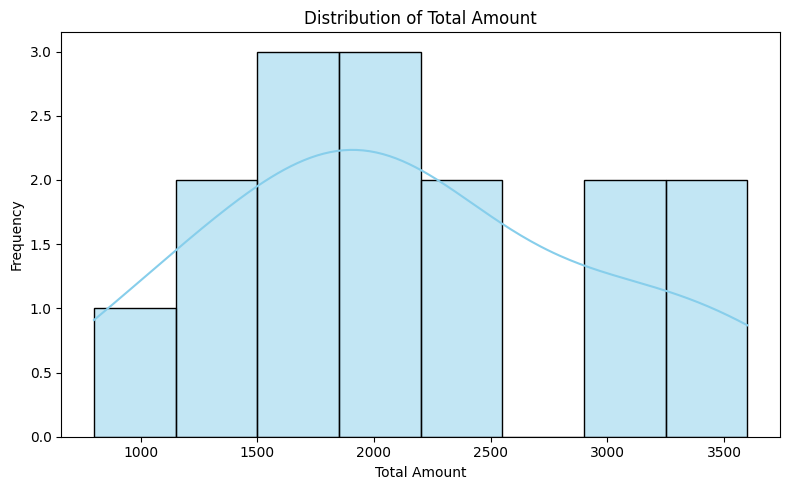

In [ ]:
# Histogram for TotalAmount
plt.figure(figsize=(8, 5))
sns.histplot(df["TotalAmount"], bins=8, kde=True, color="skyblue")
plt.title("Distribution of Total Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("outputs/charts/hist_total_amount.png")
plt.show()

/tmp/ipykernel_2786/3340782594.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="ProductCategory", palette="viridis")


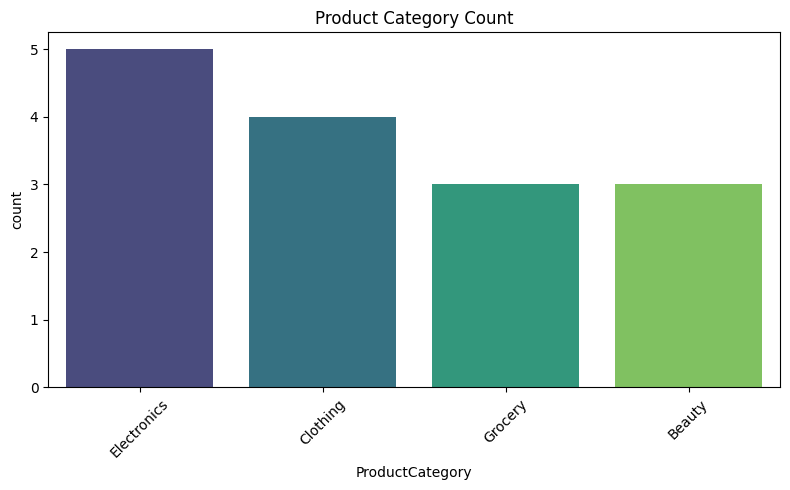

In [ ]:
# Bar chart for ProductCategory
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="ProductCategory", palette="viridis")
plt.title("Product Category Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("outputs/charts/bar_product_category.png")
plt.show()

/tmp/ipykernel_2786/4164497062.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="PaymentMethod", palette="Set2")


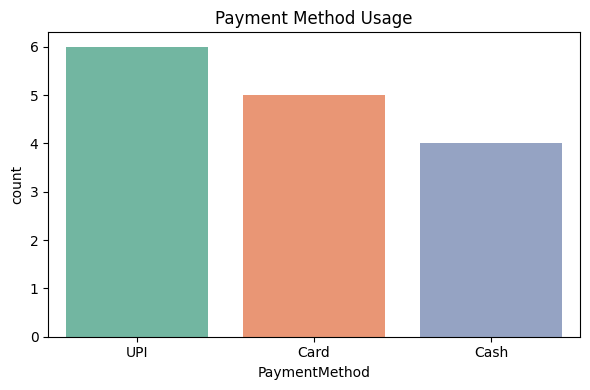

In [ ]:
# Payment Method count
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="PaymentMethod", palette="Set2")
plt.title("Payment Method Usage")
plt.tight_layout()
plt.savefig("outputs/charts/bar_payment_method.png")
plt.show()

STEP 2: SQL for Business Questions

In [ ]:
conn = sqlite3.connect("retail_sales.db")
df.to_sql("sales", conn, if_exists="replace", index=False)


15

In [ ]:
queries = {
    "1_top_5_products_by_revenue": """
        SELECT ProductName, SUM(TotalAmount) AS Revenue
        FROM sales
        GROUP BY ProductName
        ORDER BY Revenue DESC
        LIMIT 5;
    """,
    "2_monthly_sales_trend": """
        SELECT strftime('%Y-%m', OrderDate) AS Month, SUM(TotalAmount) AS MonthlyRevenue
        FROM sales
        GROUP BY Month
        ORDER BY Month;
    """,
    "3_revenue_by_category": """
        SELECT ProductCategory, SUM(TotalAmount) AS Revenue
        FROM sales
        GROUP BY ProductCategory
        ORDER BY Revenue DESC;
    """,
    "4_average_age_by_category": """
        SELECT ProductCategory, AVG(Age) AS AvgAge
        FROM sales
        GROUP BY ProductCategory;
    """,
    "5_most_used_payment_method": """
        SELECT PaymentMethod, COUNT(*) AS UsageCount
        FROM sales
        GROUP BY PaymentMethod
        ORDER BY UsageCount DESC;
    """,
    "6_top_city_by_sales": """
        SELECT City, SUM(TotalAmount) AS Revenue
        FROM sales
        GROUP BY City
        ORDER BY Revenue DESC
        LIMIT 1;
    """
}


In [ ]:
with open("sql/business_queries.sql", "w") as f:
    for name, query in queries.items():
        f.write(f"-- {name}\n{query.strip()}\n\n")

In [ ]:
print("\n========== SQL QUERY RESULTS ==========")
for name, query in queries.items():
    print(f"\n{name}")
    result = pd.read_sql_query(query, conn)
    print(result)
    result.to_csv(f"outputs/{name}.csv", index=False)


========== SQL QUERY RESULTS ==========

1_top_5_products_by_revenue
   ProductName  Revenue
0        Dress     3600
1  Smart Watch     3500
2        Jeans     3000
3   Headphones     3000
4        Saree     2500

2_monthly_sales_trend
     Month  MonthlyRevenue
0  2024-01           11900
1  2024-02            8300
2  2024-03           12000

3_revenue_by_category
  ProductCategory  Revenue
0        Clothing    11200
1     Electronics    10800
2          Beauty     6000
3         Grocery     4200

4_average_age_by_category
  ProductCategory     AvgAge
0          Beauty  30.333333
1        Clothing  31.250000
2     Electronics  31.800000
3         Grocery  36.666667

5_most_used_payment_method
  PaymentMethod  UsageCount
0           UPI           6
1          Card           5
2          Cash           4

6_top_city_by_sales
        City  Revenue
0  Hyderabad     9300


STEP 3: Multivariate Analysis & Correlation

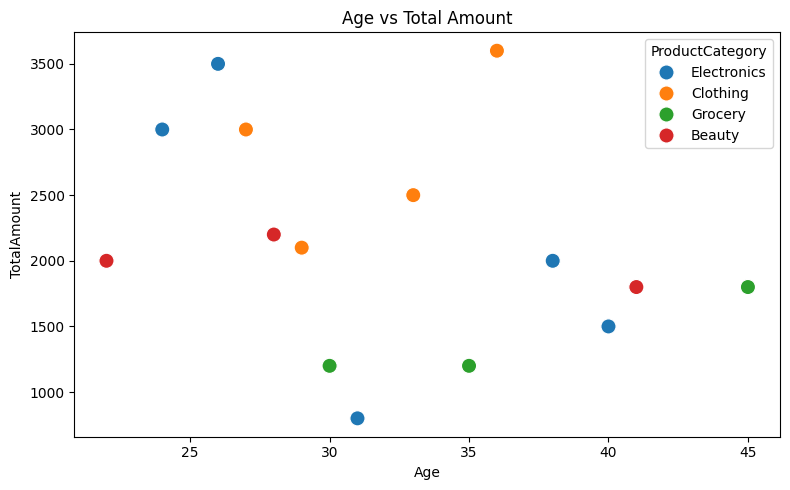

In [ ]:
# Scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Age", y="TotalAmount", hue="ProductCategory", s=120)
plt.title("Age vs Total Amount")
plt.tight_layout()
plt.savefig("outputs/charts/scatter_age_totalamount.png")
plt.show()

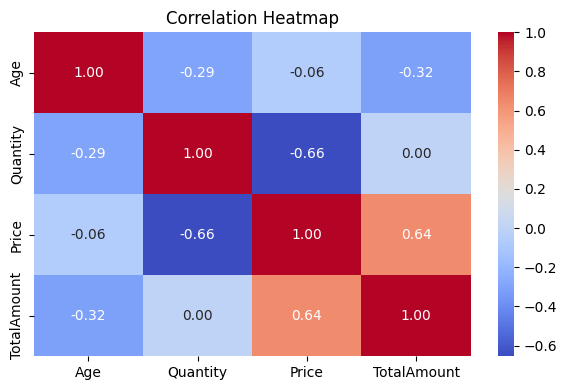

In [ ]:
# Correlation heatmap
numeric_df = df[["Age", "Quantity", "Price", "TotalAmount"]]
plt.figure(figsize=(6, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("outputs/charts/heatmap_correlation.png")
plt.show()

STEP 4: Static Dashboard Mock-up

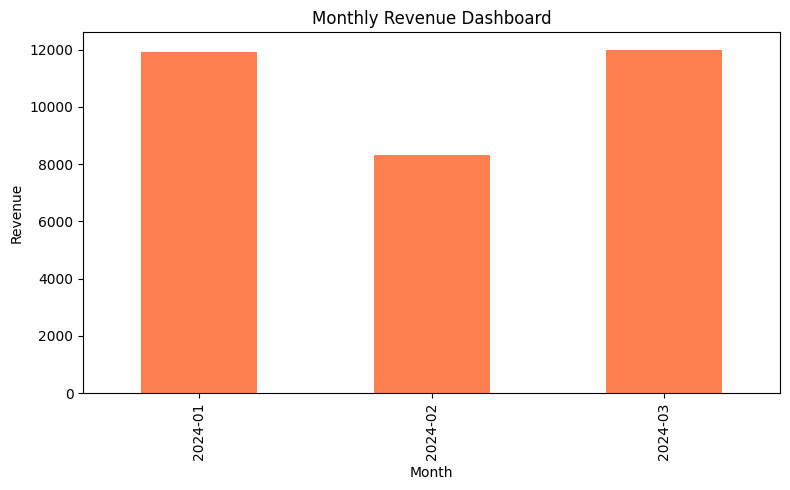


Project completed successfully!


In [19]:
monthly_sales = df.groupby(df["OrderDate"].dt.to_period("M"))["TotalAmount"].sum()

plt.figure(figsize=(8, 5))
monthly_sales.plot(kind="bar", color="coral")
plt.title("Monthly Revenue Dashboard")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.savefig("outputs/dashboard_mockup.png")
plt.show()

conn.close()
print("\nProject completed successfully!")